# Entities & Co-occurrence Network

The corpus EDA showed a recent (2025–2026) snapshot of ~1,450 abstracts
on kinase inhibitors and cancer, with broad journal coverage and
healthy MeSH overlap. This notebook turns that into a network:

1. **Run scispaCy NER** on every abstract using two specialised models
   (BC5CDR for diseases + chemicals, BioNLP13CG for genes/proteins +
   anatomy). Collapse 18 raw entity types into 5 canonical buckets.
2. **Aggregate to document-level frequency.** Filter to entities that
   appear in ≥ N abstracts — rare ones produce noisy edges with no
   support.
3. **Build the co-occurrence graph.** Two views: raw weight (popularity)
   and PMI (specificity).
4. **Analyse the graph.** Centrality, community detection, type-specific
   sub-networks (drug-gene, drug-disease).
5. **Visualise** with a static matplotlib layout and an interactive
   pyvis HTML you can pan/zoom in a browser.

Honest limitations called out as we go:

- **No UMLS/MeSH linking.** "EGFR" and "epidermal growth factor receptor"
  are different nodes. Production systems use UMLS (`scispacy.linking`);
  we don't, and we say so.
- **Co-occurrence is weak evidence.** Two entities in the same abstract
  may be co-mentioned for many reasons — including being contrasted.
  PMI helps but doesn't fix this.
- **Recent-snapshot bias.** Aurora kinase inhibitors will be
  underrepresented vs their historic importance.


## 1. Setup

In [1]:
import sys
from collections import Counter
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from src.load import load_abstracts
from src.network import (
    load_entities, entity_doc_frequency, filter_entities,
    cooccurrence_edges, build_graph, centrality_table, communities,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


## 2. Run NER

If `data/processed/entities.jsonl` doesn't exist yet, run from the
project root:

```bash
python -m src.ner
```

Expected runtime: ~30–60 sec on CPU for 1,450 abstracts with both
models. The output is one JSON line per entity occurrence.

In [2]:
ents = load_entities()
print(f"Loaded {len(ents):,} entity occurrences")
print()
print("By model:")
print(ents["model"].value_counts())
print()
print("By collapsed type:")
print(ents["type"].value_counts())
print()
print("By raw scispaCy label:")
print(ents["raw_type"].value_counts())


Loaded 49,594 entity occurrences

By model:
model
bionlp13cg    30866
bc5cdr        18728
Name: count, dtype: int64

By collapsed type:
type
DISEASE     19394
CHEMICAL    16051
GENE        10325
CELL         2630
ANATOMY      1194
Name: count, dtype: int64

By raw scispaCy label:
raw_type
DISEASE                   10000
GENE_OR_GENE_PRODUCT       9740
CANCER                     8937
CHEMICAL                   8728
SIMPLE_CHEMICAL            7323
CELL                       2630
ORGAN                       730
AMINO_ACID                  585
PATHOLOGICAL_FORMATION      457
TISSUE                      288
ANATOMICAL_SYSTEM           176
Name: count, dtype: int64


## 3. Document-level frequency

Move from "occurrences" (one paper mentioning EGFR five times = 5
rows) to "document frequency" (one paper, count = 1). This is the
right unit for co-occurrence.

In [3]:
ent_df = entity_doc_frequency(ents)
print(f"Distinct (entity, type) pairs: {len(ent_df):,}")
print()
print("Top 25 entities by document frequency:")
ent_df.head(25)


Distinct (entity, type) pairs: 10,386

Top 25 entities by document frequency:


,norm,type,doc_freq
9960,tyrosine,CHEMICAL,889
9961,tyrosine,GENE,440
9543,tki,CHEMICAL,335
7046,nsclc,DISEASE,294
6966,non-small cell lung cancer,DISEASE,257
3139,egfr,GENE,247
9610,tkis,CHEMICAL,171
9683,toxicity,DISEASE,165
3360,epidermal growth factor receptor,GENE,134
2020,cellular,CELL,114


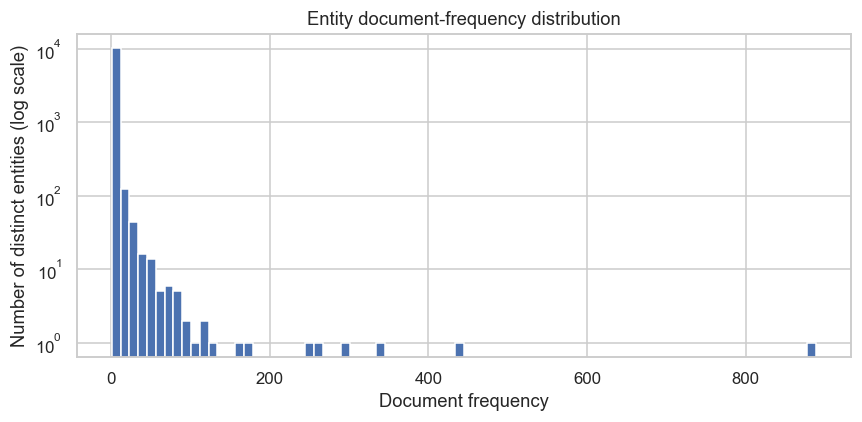

In [4]:
# Distribution of document frequency — heavy-tailed as expected
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ent_df["doc_freq"], bins=80, log=True, color="#4c72b0", edgecolor="white")
ax.set_xlabel("Document frequency")
ax.set_ylabel("Number of distinct entities (log scale)")
ax.set_title("Entity document-frequency distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_entity_df_distribution.png", bbox_inches="tight")
plt.show()


## 4. Top entities by type

Sanity check: do the top extracted entities look reasonable for a
"kinase inhibitor cancer" corpus? If yes, NER is working. If "patient"
or "treatment" dominates, the stop-list needs widening.

In [5]:
for t in ["CHEMICAL", "GENE", "DISEASE", "CELL", "ANATOMY"]:
    sub = ent_df[ent_df["type"] == t].head(15)
    print(f"=== Top 15 {t} ===")
    for _, r in sub.iterrows():
        print(f"  {r['doc_freq']:>4d}  {r['norm']}")
    print()


=== Top 15 CHEMICAL ===
   889  tyrosine
   335  tki
   171  tkis
    76  lenvatinib
    73  imatinib
    63  multi-kinase
    61  orr
    59  sorafenib
    56  egfr-tkis
    52  second-line
    49  cabozantinib
    48  ici
    43  egfr-tki
    36  dasatinib
    35  nivolumab

=== Top 15 GENE ===
   440  tyrosine
   247  egfr
   134  epidermal growth factor receptor
    78  egfr tyrosine kinase
    54  bruton tyrosine kinase
    53  alk
    46  epidermal growth factor receptor tyrosine kinase
    45  her2
    42  tp53
    37  met
    34  bruton's tyrosine kinase
    33  cd8
    27  akt
    27  pd-1
    27  ici

=== Top 15 DISEASE ===
   294  nsclc
   257  non-small cell lung cancer
   165  toxicity
   112  death
   105  hepatocellular carcinoma
    98  hcc
    94  renal cell carcinoma
    88  breast cancer
    87  lung cancer
    85  antitumor
    81  anticancer
    79  chronic myeloid leukemia
    78  cml
    71  toxicities
    64  lung adenocarcinoma

=== Top 15 CELL ===
   114  cell

## 5. Filter and build edges

Drop entities below a document-frequency threshold. With 1,450
abstracts, **min_count = 8** is a reasonable starting point — it
keeps strongly-supported entities while pruning the noisy long tail.
Raise it for a sparser, more interpretable graph; lower it for more
detail at the cost of clutter.

Restrict to the four most informative types: CHEMICAL, GENE, DISEASE,
CELL. Anatomy adds little to drug-target-disease analysis.

In [6]:
MIN_COUNT = 8
KEEP_TYPES = ["CHEMICAL", "GENE", "DISEASE", "CELL"]

ents_f = filter_entities(ents, min_count=MIN_COUNT, keep_types=KEEP_TYPES)
print(f"After filter (min_count={MIN_COUNT}, types={KEEP_TYPES}):")
print(f"  occurrences: {len(ents_f):,}")
print(f"  distinct entities: {ents_f.groupby(['norm', 'type']).ngroups:,}")


After filter (min_count=8, types=['CHEMICAL', 'GENE', 'DISEASE', 'CELL']):
  occurrences: 24,628
  distinct entities: 375


In [7]:
edges = cooccurrence_edges(ents_f)
print(f"Edges: {len(edges):,}")
print()
print("Top 25 edges by raw co-occurrence weight:")
edges.head(25)


Edges: 14,224

Top 25 edges by raw co-occurrence weight:


,a,type_a,b,type_b,weight,pmi
0,tyrosine,CHEMICAL,tyrosine,GENE,439,0.690526
1,tki,CHEMICAL,tyrosine,CHEMICAL,299,0.529793
2,nsclc,DISEASE,tyrosine,CHEMICAL,222,0.288552
3,non-small cell lung cancer,DISEASE,nsclc,DISEASE,213,2.019261
4,egfr,GENE,tyrosine,CHEMICAL,190,0.315297
5,non-small cell lung cancer,DISEASE,tyrosine,CHEMICAL,189,0.250426
6,tki,CHEMICAL,tyrosine,GENE,181,0.820317
7,tkis,CHEMICAL,tyrosine,CHEMICAL,156,0.561358
8,egfr,GENE,nsclc,DISEASE,154,1.608595
9,egfr,GENE,non-small cell lung cancer,DISEASE,118,1.418499


In [8]:
print("Top 25 edges by PMI (filtered to weight ≥ 5):")
edges_pmi = edges[edges["weight"] >= 5].sort_values("pmi", ascending=False)
edges_pmi.head(25)


Top 25 edges by PMI (filtered to weight ≥ 5):


,a,type_a,b,type_b,weight,pmi
894,cdkn1a,CHEMICAL,cdkn1a,GENE,8,7.489848
852,jak,CHEMICAL,jak,GENE,8,7.489848
1062,pancreatic ductal adenocarcinoma,DISEASE,pdac,DISEASE,7,7.127278
717,rkip,CHEMICAL,rkip,GENE,9,7.030416
844,pk,CHEMICAL,pk,GENE,8,7.030416
1171,chronic lymphocytic leukemia/small lymphocytic...,DISEASE,cll/sll,DISEASE,6,6.752882
354,mek,CHEMICAL,mek,GENE,14,6.682493
1593,mmr,CHEMICAL,mmr,GENE,5,6.641851
763,acute myeloid leukemia,DISEASE,flt3,GENE,8,6.582957
336,kit,CHEMICAL,kit,GENE,14,6.582957


## 6. Build the graph

**MIN_EDGE_WEIGHT** is the second sparsity dial. With min_count=8 and
min_edge_weight=4, we usually get ~100–200 nodes, ~300–800 edges —
manageable for visualisation.

In [9]:
MIN_EDGE_WEIGHT = 4
G = build_graph(edges, min_weight=MIN_EDGE_WEIGHT)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Density: {nx.density(G):.4f}")
print(f"Components: {nx.number_connected_components(G)}")
giant = max(nx.connected_components(G), key=len)
print(f"Giant component: {len(giant)} nodes ({len(giant)/G.number_of_nodes():.0%})")


Graph: 347 nodes, 1934 edges
Density: 0.0322
Components: 2
Giant component: 344 nodes (99%)


## 7. Hubs — who's central?

Weighted degree = total edge weight (popularity). Betweenness =
how often a node sits on shortest paths between others (bridging
role). These usually highlight different things.

In [10]:
cent = centrality_table(G)
print("Top 25 by weighted degree:")
cent.head(25)


Top 25 by weighted degree:


,node,type,degree,weighted_degree,betweenness
0,tyrosine,CHEMICAL,321,4234,0.702134
1,tki,CHEMICAL,152,1835,0.067281
2,nsclc,DISEASE,107,1629,0.024479
3,egfr,GENE,108,1521,0.030643
4,non-small cell lung cancer,DISEASE,98,1017,0.022708
5,toxicity,DISEASE,93,828,0.023923
6,tkis,CHEMICAL,96,784,0.019841
7,epidermal growth factor receptor,GENE,58,770,0.003384
8,hepatocellular carcinoma,DISEASE,45,530,0.004026
9,hcc,DISEASE,43,518,0.003511


In [11]:
print("Top 15 by betweenness centrality (bridges):")
cent.sort_values("betweenness", ascending=False).head(15)


Top 15 by betweenness centrality (bridges):


,node,type,degree,weighted_degree,betweenness
0,tyrosine,CHEMICAL,321,4234,0.702134
1,tki,CHEMICAL,152,1835,0.067281
17,cellular,CELL,52,323,0.034222
3,egfr,GENE,108,1521,0.030643
2,nsclc,DISEASE,107,1629,0.024479
5,toxicity,DISEASE,93,828,0.023923
4,non-small cell lung cancer,DISEASE,98,1017,0.022708
6,tkis,CHEMICAL,96,784,0.019841
85,malignancies,DISEASE,15,84,0.009900
15,antitumor,DISEASE,46,337,0.009124


## 8. Communities

Greedy modularity finds tightly-connected sub-groups. With a
biomedical corpus we expect to see clusters that map to disease
contexts (e.g. CML + imatinib + BCR-ABL; NSCLC + EGFR + osimertinib +
erlotinib).

In [12]:
comm_map = communities(G)
n_comms = len(set(comm_map.values()))
print(f"Found {n_comms} communities")

comm_df = pd.DataFrame([
    {"node": n, "type": G.nodes[n]["type"], "community": c,
     "weighted_degree": dict(G.degree(weight='weight'))[n]}
    for n, c in comm_map.items()
])
print()
print("Community sizes:")
print(comm_df["community"].value_counts().sort_index())


Found 13 communities

Community sizes:
community
0     129
1      96
2      78
3      23
4       5
5       4
6       3
7       3
8       2
9       1
10      1
11      1
12      1
Name: count, dtype: int64


In [13]:
print("Top 5 nodes (by weighted degree) per community:")
for cid in sorted(comm_df["community"].unique()):
    sub = (comm_df[comm_df["community"] == cid]
           .sort_values("weighted_degree", ascending=False)
           .head(5))
    nodes_str = ", ".join(f"{r['node']} ({r['type'][0]})"
                          for _, r in sub.iterrows())
    size = (comm_df["community"] == cid).sum()
    print(f"  C{cid} (n={size:>3}): {nodes_str}")


Top 5 nodes (by weighted degree) per community:
  C0 (n=129): tyrosine (C), chronic myeloid leukemia (D), imatinib (C), bruton tyrosine kinase (G), cml (D)
  C1 (n= 96): toxicity (D), hepatocellular carcinoma (D), hcc (D), death (D), antitumor (D)
  C2 (n= 78): tki (C), nsclc (D), egfr (G), non-small cell lung cancer (D), tkis (C)
  C3 (n= 23): renal cell carcinoma (D), orr (C), cabozantinib (C), ici (C), rcc (D)
  C4 (n=  5): mek (C), erk (G), mapk (G), trametinib (C), mitogen-activated protein kinase (G)
  C5 (n=  4): pdac (D), pancreatic cancer (D), pancreatic ductal adenocarcinoma (D), gemcitabine (C)
  C6 (n=  3): aml (D), acute myeloid leukemia (D), flt3 (G)
  C7 (n=  3): jak (C), ruxolitinib (C), janus kinase (G)
  C8 (n=  2): a549 (C), a549 cells (C)
  C9 (n=  1): ret (D)
  C10 (n=  1): rkip (C)
  C11 (n=  1): pk (C)
  C12 (n=  1): cdkn1a (C)


## 9. Static visualisation

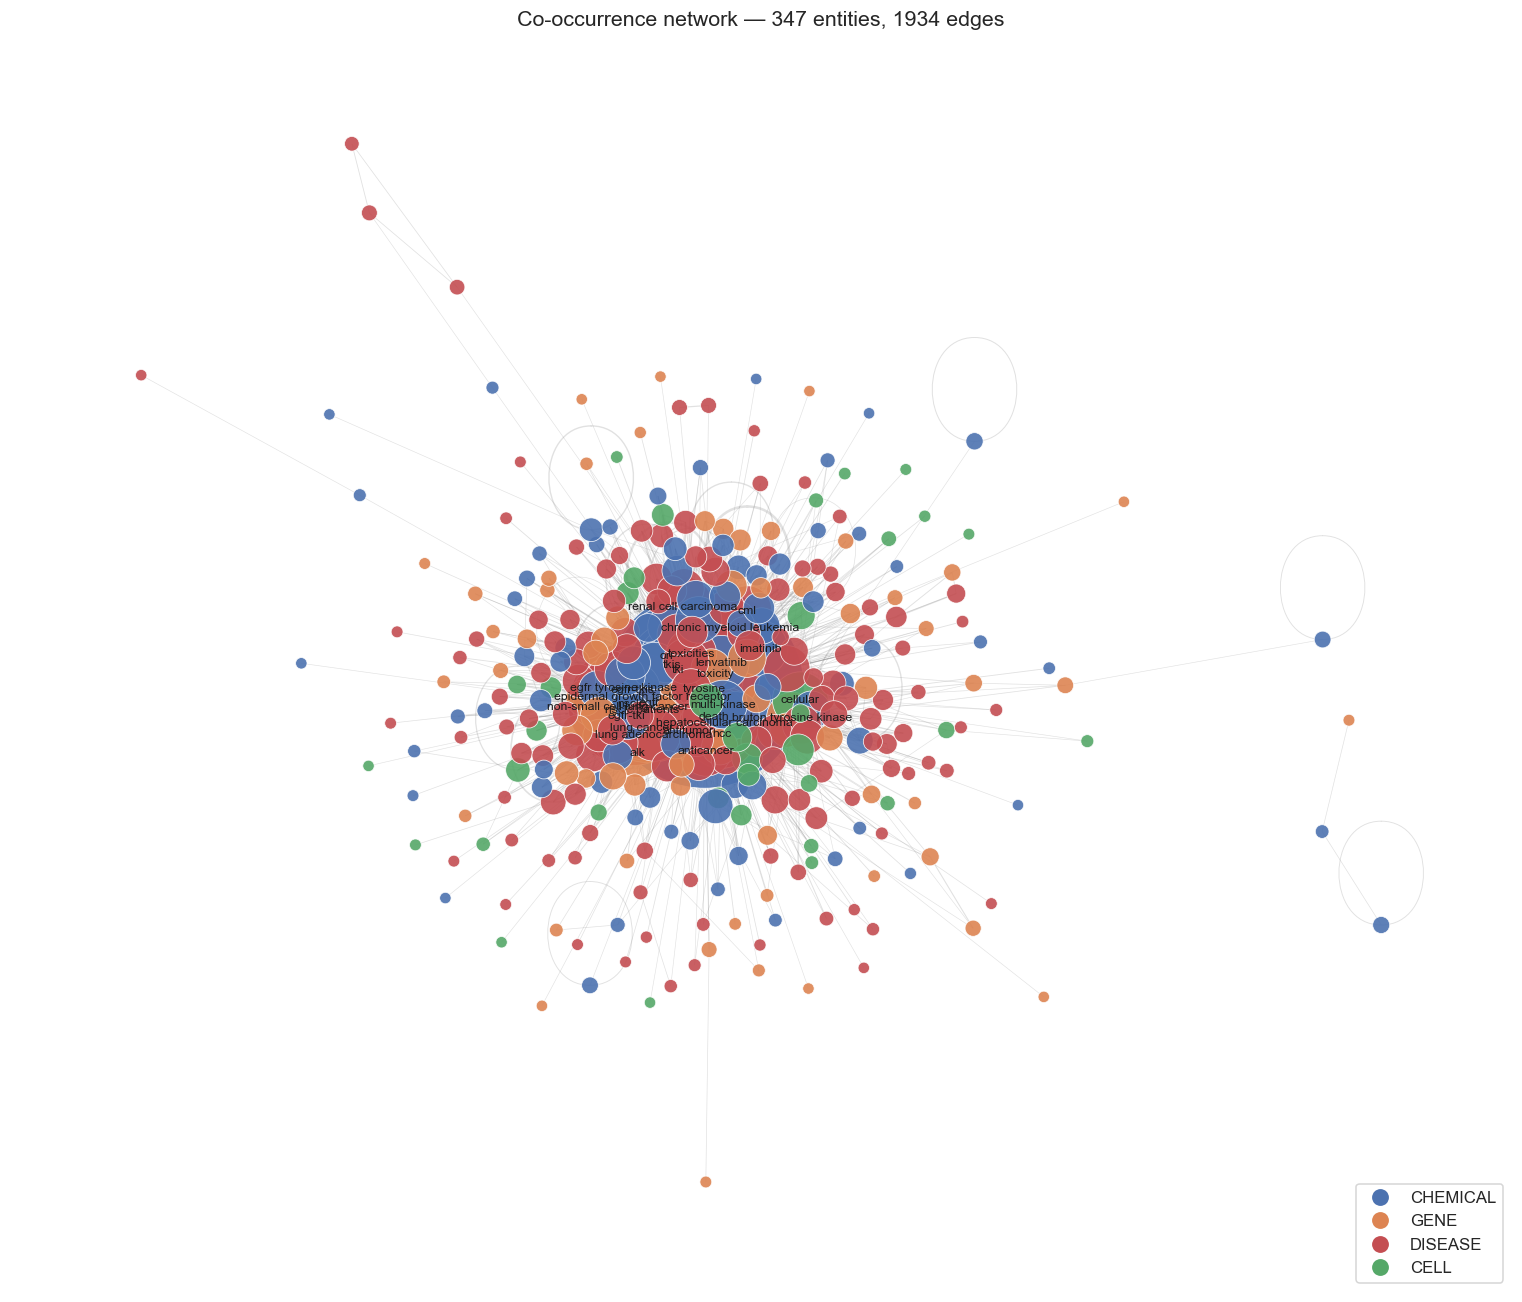

In [14]:
# Layout: spring layout with seed for reproducibility
pos = nx.spring_layout(G, seed=42, k=0.5, iterations=80)

# Color by canonical type
TYPE_COLORS = {
    "CHEMICAL": "#4c72b0",   # blue
    "GENE":     "#dd8452",   # orange
    "DISEASE":  "#c44e52",   # red
    "CELL":     "#55a868",   # green
}
node_colors = [TYPE_COLORS.get(G.nodes[n]["type"], "#888") for n in G.nodes()]

# Size by weighted degree
wdeg = dict(G.degree(weight="weight"))
node_sizes = [40 + wdeg[n] * 4 for n in G.nodes()]

# Edge widths from weight (capped to keep busy areas readable)
edge_widths = [min(0.2 + G[u][v]["weight"] * 0.05, 3.0) for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=edge_widths,
                       edge_color="#888")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                       node_color=node_colors, alpha=0.9, linewidths=0.5,
                       edgecolors="white")

# Label only the top-N most central nodes to keep the picture readable
top_label_n = 30
top_nodes = set(cent.head(top_label_n)["node"])
labels = {n: n for n in G.nodes() if n in top_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8)

# Legend
from matplotlib.lines import Line2D
legend = [Line2D([0], [0], marker='o', linestyle='', color=c,
                  markersize=10, label=t)
          for t, c in TYPE_COLORS.items()]
ax.legend(handles=legend, loc="lower right", frameon=True)
ax.set_title(f"Co-occurrence network — {G.number_of_nodes()} entities, "
             f"{G.number_of_edges()} edges", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_network_overview.png", bbox_inches="tight", dpi=150)
plt.show()


## 10. Drug ↔ gene/disease sub-networks

Slicing the graph by edge endpoints answers focused questions: *which
drugs are most associated with which targets?*

In [15]:
def filter_subgraph_by_types(G, type_pairs):
    """Return a subgraph keeping only edges whose endpoint type pair
    is in `type_pairs` (each pair is a frozenset of two type strings)."""
    H = nx.Graph()
    for u, v, d in G.edges(data=True):
        tu = G.nodes[u]["type"]
        tv = G.nodes[v]["type"]
        if frozenset({tu, tv}) in type_pairs:
            for n in (u, v):
                if n not in H:
                    H.add_node(n, **G.nodes[n])
            H.add_edge(u, v, **d)
    return H


drug_target = filter_subgraph_by_types(G, {frozenset({"CHEMICAL", "GENE"})})
drug_disease = filter_subgraph_by_types(G, {frozenset({"CHEMICAL", "DISEASE"})})
print(f"Drug ↔ Gene subgraph: {drug_target.number_of_nodes()} nodes, "
      f"{drug_target.number_of_edges()} edges")
print(f"Drug ↔ Disease subgraph: {drug_disease.number_of_nodes()} nodes, "
      f"{drug_disease.number_of_edges()} edges")


Drug ↔ Gene subgraph: 102 nodes, 182 edges
Drug ↔ Disease subgraph: 215 nodes, 565 edges


In [16]:
def top_edges(H, n=20):
    return (pd.DataFrame([
        {"a": u, "b": v, **d}
        for u, v, d in H.edges(data=True)
    ]).sort_values("weight", ascending=False).head(n))

print("Top drug ↔ gene edges:")
print(top_edges(drug_target).to_string())
print()
print("Top drug ↔ disease edges:")
print(top_edges(drug_disease).to_string())


Top drug ↔ gene edges:
                                    a                                                 b  weight       pmi
60                               egfr                                               tki     105  0.867709
80   epidermal growth factor receptor                                               tki      63  1.013021
3                            tyrosine                            bruton tyrosine kinase      54  0.693808
0                            tyrosine                                              egfr      48 -0.654916
4                            tyrosine  epidermal growth factor receptor tyrosine kinase      46  0.693808
61                               egfr                                              tkis      43  0.549893
62                               egfr                                         egfr-tkis      38  1.982053
7                            tyrosine                          bruton's tyrosine kinase      34  0.693808
1                      

## 11. Interactive HTML visualisation

In [17]:
# pyvis renders an interactive HTML you can open and pan/zoom
from pyvis.network import Network

net = Network(height="700px", width="100%", bgcolor="#ffffff",
              font_color="#222", notebook=False, cdn_resources="in_line")
net.barnes_hut(spring_length=120, spring_strength=0.02, damping=0.4)

for n, d in G.nodes(data=True):
    color = TYPE_COLORS.get(d["type"], "#888")
    size = 10 + wdeg[n] * 0.8
    title = f"{n}\n{d['type']} | weighted_degree={wdeg[n]}"
    net.add_node(n, label=n, color=color, size=size, title=title)

for u, v, d in G.edges(data=True):
    net.add_edge(u, v, value=d["weight"],
                 title=f"weight={d['weight']}, pmi={d['pmi']:.2f}")

out_html = FIG_DIR.parent / "network.html"
net.write_html(str(out_html), notebook=False)
print(f"Interactive network → {out_html}")
print("Open it in a browser to explore.")


Interactive network → ../reports/network.html
Open it in a browser to explore.
